In [59]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..')
sys.path.append('../gen_data/')
from utils import julio
import importlib
# importlib.reload(julio)
import pandas as pd
import src.observables as obs
importlib.reload(obs)
import utils.io as io
from read_corrs import read_corrs, select_dV
import matplotlib as mpl
mpl.style.use('aps.mplstyle')
import set_size_helper as ssh
# importlib.reload(ssh)

from scipy.fftpack import fft
import matplotlib as mpl
mpl.style.use('aps.mplstyle')

In [46]:
all_files = []
for N in (64, 128, 256, ):
    for dV in np.arange(3.2, 4.0, 0.05):
        filename = julio.corr_filename_builder(N, 1.0, 0.1, 0.8, dV=dV)
        if os.path.exists(filename):
            all_files.append(filename)
df = julio.load_correlations_files(all_files)
df_i = pd.DataFrame()

idmrg_file_list_dict = {100 : '../../data/iDMRG/rev/scanChi100/corrs/results.h5',
                        200 : '../../data/iDMRG/rev/scanChi200/corrs/results.h5', 
                        400 : '../../data/iDMRG/rev/scanChi200/corrs/results.h5', 
                        800 : '../../data/iDMRG/scanChi800/corrs/results.h5',
                        1000: '../../data/iDMRG/scanChi1000/corrs/results.h5',
}
for chi, idmrg_file in idmrg_file_list_dict.items():
    df_i_chi = read_corrs(idmrg_file)
    df_i_chi['chi'] = chi
    df_i = pd.concat([df_i, df_i_chi])
df.keys(), df_i.keys()

(Index(['szmat', 'chargemat', 'spmmat', 'elecupmat', 'elecdnmat', 'sz_expect',
        'ntot_expect', 'xspin2', 'spin2vec', 'params', 'N', 'dV', 'Vpm',
        'szconn', 'chargeconn', 'spmconn', 'electron_conn', 'filename'],
       dtype='str'),
 Index(['basename', 'src_file', 'dV', 'mean_Sz', 'mean_fill', 'xi',
        'model_params', 'diagnostics', 'charge_corr', 'spinz_corr', 'spsm_corr',
        'electron_corr', 'spin2_corr', 'chi'],
       dtype='str'))

No data available for N = 256, dVval = 3.950


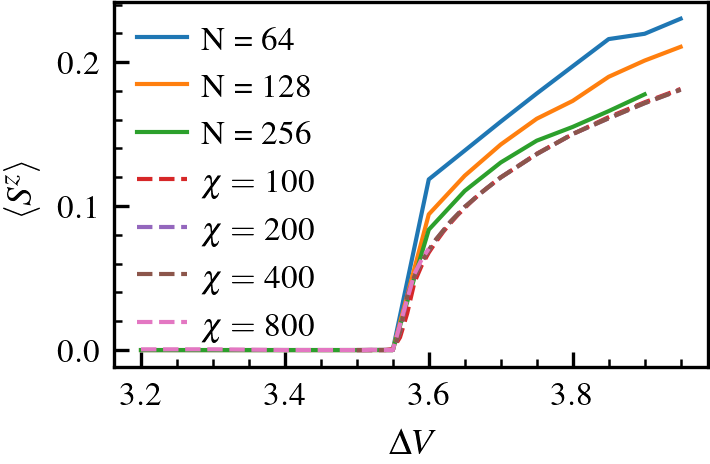

In [69]:
fig, ax = plt.subplots(1)
fig_width = ssh.set_size(subplots=(1,1), fraction=0.75)
fig.set_size_inches(fig_width)
for nval in (64, 128, 256):
    dVlist = []
    magzlist = []
    for dVval in np.arange(3.2, 4.0, 0.05):
        seldf = julio.select_N_dv_from_df(nval, dVval, df)
        do_f = True
        try : 
            magz = seldf['sz_expect'].iloc[0][10:-10].mean()
        except Exception: 
            print(f"No data available for N = {nval}, dVval = {dVval:.3f}")
            do_f = False
        if do_f :
            dVlist.append(dVval)
            magzlist.append(magz)
    ax.plot(dVlist, np.abs(magzlist), label=f'N = {nval}')

for chival in [100, 200, 400, 800]:
    dVlist_i = []
    magzlist_i = []
    for dVval in np.arange(3.2, 4.0, 0.01):
        do_i = True
        tmp_seldf_i = df_i[df_i['chi']==chival]
        seldf_i = select_dV(tmp_seldf_i, dVval, atol=1e-7)
        try : 
            magz_i = seldf_i['mean_Sz'].iloc[0]
        except Exception: 
            # print(f"No iDMRG data available for dV = {dVval:.3f}")
            do_i = False
        if do_i : 
            dVlist_i.append(dVval)
            magzlist_i.append(magz_i)
    ax.plot(dVlist_i, np.abs(magzlist_i), ls='--', label=rf'$\chi = {{{chival}}}$')

    
# ax.plot(dVlist_i, magzlist_i, label=r'iDMRG $\chi=200$')
ax.legend()
ax.set_xlabel(r'$\Delta V$')
ax.set_ylabel(r'$\langle S^z \rangle$')
fig.savefig('figures/ShowMagAcrossCrit.pdf', bbox_inches='tight')


In [72]:
tmp_seldf_i = df_i[df_i['chi']==200]
seldf_i = select_dV(tmp_seldf_i, 3.8, atol=1e-7)
seldf_i['mean_Sz'], seldf_i['mean_fill'], seldf_i['xi']

(0    0.150062
 Name: mean_Sz, dtype: float64,
 0    0.5
 Name: mean_fill, dtype: float64,
 0    60.087782
 Name: xi, dtype: float64)